In [1]:
import numpy as np
import matplotlib.pyplot as plt

iris = np.genfromtxt('iris_full.csv', dtype=None, delimiter=',', skip_header=1) 
X = iris[:, :4]
y = iris[:, 4]

intercept = np.ones((X.shape[0], 1))
X = np.concatenate((intercept, X), axis=1)
N = X.shape[0]

# shuffle
inds = np.arange(X.shape[0])
np.random.shuffle(inds)

X = X[inds]
y = y[inds]

print(X.shape)
print(y.shape)

(100, 5)
(100,)


In [2]:
def sigmoid_function(z):
    return 1 / (1 + np.exp(-z))

def loss_function(y_hat, y):
    #return (-y*np.log(y_hat) - (1-y)*np.log(1-y_hat)).mean()
    return ( -y.T.dot(np.log(y_hat)) - (1 - y).T.dot(np.log(1 - y_hat)) ) / N

def predict(X, theta):    
    y_hat = sigmoid_function(np.dot(X, theta))
    return y_hat

def compute_gradient(X, y_hat, y):
    return np.dot(X.T, (y_hat - y)) / y.size

In [3]:
# training
lr=0.01
num_iter=100

theta = np.array([0.1, 0.5, 0.1, 0.5, -0.1])
losses = []
accs   = []

for i in range(num_iter):
    # predict z
    y_hat = predict(X, theta)
    
    # compute loss
    loss = loss_function(y_hat, y)

    # compute mean of gradient
    gradient = compute_gradient(X, y_hat, y)
    
    # update
    theta -= lr*gradient     
    
    
    
    # ==========for debug
    # loss
    losses.append(loss)

    # accuracy for training
    preds = predict(X, theta).round()
    acc = (preds == y).mean()
    accs.append(acc) 

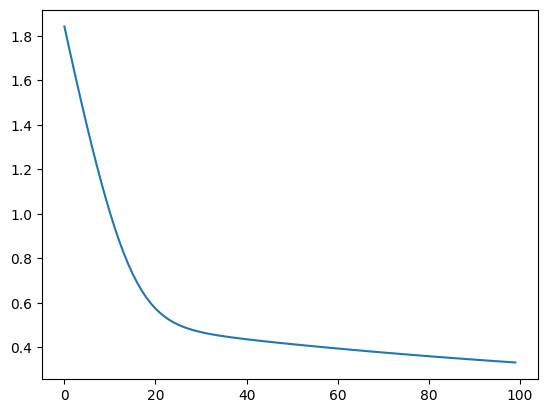

In [4]:
# show figures
plt.plot(losses)
plt.show()

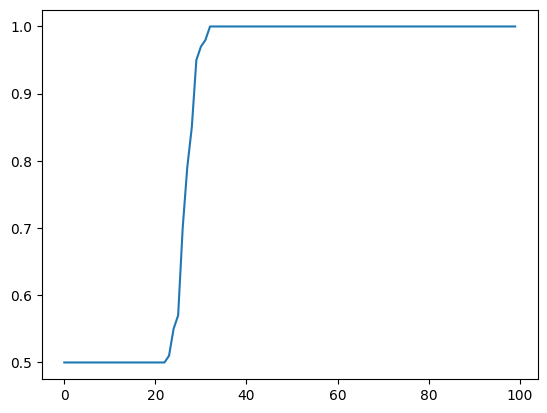

In [5]:
plt.plot(accs)
plt.show()

In [6]:
preds = predict(X, theta).round()
print(preds)
print(y)

[1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1.
 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1.]
[1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1.
 0. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 0. 1. 1. 0.
 1. 1. 0. 1.]
